In [1]:
from pathlib import Path

# Support kernels started in the repository root or notebooks directory.
PROJECT = Path.cwd().resolve()
if PROJECT.name == "notebooks":
    PROJECT = PROJECT.parent
if not (PROJECT / "notebooks").is_dir() or not (PROJECT / "README.md").is_file():
    raise RuntimeError("Start the notebook from the repository root or notebooks directory.")

import pandas as pd
import matplotlib.pyplot as plt

analysis = pd.read_parquet(
    PROJECT / "data" / "processed" / "cereal_analysis.parquet"
)

print(analysis.shape)
analysis.head()

Matplotlib is building the font cache; this may take a moment.


(4706287, 13)


,STORE,UPC,WEEK,MOVE,QTY,PRICE,SALE,PROFIT,OK,DESCRIP,SIZE,UNIT_PRICE,REVENUE
0,2,1313000002,1,19,1,1.69,None,16.51,1,NAB SHREDDED WHEAT,10 OZ,1.69,32.11
1,2,1313000002,2,21,1,1.69,None,16.57,1,NAB SHREDDED WHEAT,10 OZ,1.69,35.49
2,2,1313000002,3,17,1,1.69,None,16.57,1,NAB SHREDDED WHEAT,10 OZ,1.69,28.73
3,2,1313000002,4,25,1,1.69,None,16.57,1,NAB SHREDDED WHEAT,10 OZ,1.69,42.25
4,2,1313000002,5,27,1,1.69,None,16.57,1,NAB SHREDDED WHEAT,10 OZ,1.69,45.63


## 1. Product-Level Performance

First, I examine which products account for the largest sales volume and revenue.
This helps identify commercially important products for deeper pricing analysis.

In [2]:
product_summary = (
    analysis.groupby(["UPC", "DESCRIP", "SIZE"])
    .agg(
        total_units=("MOVE", "sum"),
        total_revenue=("REVENUE", "sum"),
        avg_unit_price=("UNIT_PRICE", "mean"),
        observations=("MOVE", "size"),
        stores=("STORE", "nunique"),
        weeks=("WEEK", "nunique")
    )
    .reset_index()
)

product_summary.sort_values(
    "total_revenue",
    ascending=False
).head(15)

,UPC,DESCRIP,SIZE,total_units,total_revenue,avg_unit_price,observations,stores,weeks
71,1600066610,CHEERIOS,15 OZ,2011819,5715980.70,3.157275,29679,93,366
70,1600066590,HONEY NUT CHEERIOS,14 OZ,1512370,4154655.73,3.122661,29537,93,366
268,3800001520,KELLOGG'S FROSTED FL,20 OZ,1322703,3931466.34,3.536368,29690,93,366
277,3800001720,KELLOGGS FRUIT LOOPS,15 OZ,1208611,3589030.75,3.408135,29724,93,366
242,3800000120,KELLOGGS CORN FLAKES,18 OZ,1830189,3488292.49,2.301682,29787,93,366
69,1600066510,CHEERIOS,10 OZ,1560241,3464034.91,2.330605,29379,93,366
267,3800001510,KELLOGG'S FROSTED FL,15 OZ,1287272,3326669.72,2.884128,29654,93,366
272,3800001621,KELLOGGS SPECIAL K,18 OZ,814409,3143528.92,4.130230,29773,93,366
259,3800001011,KELLOGGS CORN POPS,15 OZ,1010399,3132156.62,3.426082,29723,93,366
271,3800001611,KELLOGGS SPECIAL K,12 OZ,1077255,3120524.23,2.984897,29771,93,366


In [3]:
total_revenue = product_summary["total_revenue"].sum()

top_10_revenue = (
    product_summary
    .nlargest(10, "total_revenue")["total_revenue"]
    .sum()
)

print(
    "Top 10 products' share of revenue:",
    round(top_10_revenue / total_revenue * 100, 2),
    "%"
)

Top 10 products' share of revenue: 14.15 %


In [4]:
product_summary.sort_values(
    "total_units",
    ascending=False
)[
    ["UPC", "DESCRIP", "SIZE",
     "total_units", "total_revenue", "avg_unit_price"]
].head(15)

,UPC,DESCRIP,SIZE,total_units,total_revenue,avg_unit_price
71,1600066610,CHEERIOS,15 OZ,2011819,5715980.70,3.157275
242,3800000120,KELLOGGS CORN FLAKES,18 OZ,1830189,3488292.49,2.301682
69,1600066510,CHEERIOS,10 OZ,1560241,3464034.91,2.330605
70,1600066590,HONEY NUT CHEERIOS,14 OZ,1512370,4154655.73,3.122661
268,3800001520,KELLOGG'S FROSTED FL,20 OZ,1322703,3931466.34,3.536368
267,3800001510,KELLOGG'S FROSTED FL,15 OZ,1287272,3326669.72,2.884128
277,3800001720,KELLOGGS FRUIT LOOPS,15 OZ,1208611,3589030.75,3.408135
240,3800000110,KELLOGGS CORN FLAKES,12 OZ,1167781,2069515.31,1.832043
271,3800001611,KELLOGGS SPECIAL K,12 OZ,1077255,3120524.23,2.984897
247,3800000520,KELLOGGS RICE KRISPI,15 OZ,1063040,2482338.29,2.439449


## 2. Price Variation

Estimating price elasticity requires meaningful historical variation in price.
I examine the number and range of observed prices for each product to determine
which high-volume products are suitable for elasticity analysis.

In [5]:
price_summary = (
    analysis.groupby(["UPC", "DESCRIP", "SIZE"])
    .agg(
        avg_price=("UNIT_PRICE", "mean"),
        min_price=("UNIT_PRICE", "min"),
        max_price=("UNIT_PRICE", "max"),
        price_std=("UNIT_PRICE", "std"),
        unique_prices=("UNIT_PRICE", "nunique")
    )
    .reset_index()
)

price_summary["price_range"] = (
    price_summary["max_price"] - price_summary["min_price"]
)

price_summary.head()

,UPC,DESCRIP,SIZE,avg_price,min_price,max_price,price_std,unique_prices,price_range
0,1313000002,NAB SHREDDED WHEAT,10 OZ,1.918228,1.54,2.45,0.188226,73,0.91
1,1313000005,NABISCO SHREDDED WHE,15 OZ,2.623214,1.00,3.95,0.303367,151,2.95
2,1313000032,NABISCO 100% BRAN,17 OZ,2.717176,1.39,3.45,0.344167,109,2.06
3,1313000050,NAB SPOON SIZE SHRED,23.45O,4.013458,3.29,4.69,0.299416,104,1.40
4,1313000054,NAB SPOON SIZE SHRED,17.2 O,3.276089,1.47,3.85,0.334968,143,2.38


In [6]:
product_analysis = product_summary.merge(
    price_summary,
    on=["UPC", "DESCRIP", "SIZE"]
)

product_analysis.sort_values(
    "total_revenue",
    ascending=False
)[
    [
        "UPC", "DESCRIP", "SIZE",
        "total_units", "total_revenue",
        "avg_price", "min_price", "max_price",
        "price_std", "unique_prices", "price_range"
    ]
].head(20)

,UPC,DESCRIP,SIZE,total_units,total_revenue,avg_price,min_price,max_price,price_std,unique_prices,price_range
71,1600066610,CHEERIOS,15 OZ,2011819,5715980.70,3.157275,0.99,3.79,0.355257,226,2.80
70,1600066590,HONEY NUT CHEERIOS,14 OZ,1512370,4154655.73,3.122661,0.99,3.99,0.369201,249,3.00
268,3800001520,KELLOGG'S FROSTED FL,20 OZ,1322703,3931466.34,3.536368,0.99,4.29,0.469339,218,3.30
277,3800001720,KELLOGGS FRUIT LOOPS,15 OZ,1208611,3589030.75,3.408135,1.28,4.16,0.462108,218,2.88
242,3800000120,KELLOGGS CORN FLAKES,18 OZ,1830189,3488292.49,2.301682,0.92,2.95,0.430332,180,2.03
69,1600066510,CHEERIOS,10 OZ,1560241,3464034.91,2.330605,1.09,2.85,0.244472,159,1.76
267,3800001510,KELLOGG'S FROSTED FL,15 OZ,1287272,3326669.72,2.884128,0.99,3.99,0.357399,221,3.00
272,3800001621,KELLOGGS SPECIAL K,18 OZ,814409,3143528.92,4.130230,1.99,4.95,0.478722,180,2.96
259,3800001011,KELLOGGS CORN POPS,15 OZ,1010399,3132156.62,3.426082,1.02,4.05,0.403999,182,3.03
271,3800001611,KELLOGGS SPECIAL K,12 OZ,1077255,3120524.23,2.984897,1.99,3.45,0.342189,133,1.46


In [7]:
product_analysis["price_cv"] = (
    product_analysis["price_std"] /
    product_analysis["avg_price"]
)

product_analysis.sort_values(
    "total_revenue",
    ascending=False
)[
    [
        "UPC", "DESCRIP", "SIZE",
        "total_revenue",
        "avg_price",
        "unique_prices",
        "price_range",
        "price_cv"
    ]
].head(20)

,UPC,DESCRIP,SIZE,total_revenue,avg_price,unique_prices,price_range,price_cv
71,1600066610,CHEERIOS,15 OZ,5715980.70,3.157275,226,2.80,0.112520
70,1600066590,HONEY NUT CHEERIOS,14 OZ,4154655.73,3.122661,249,3.00,0.118233
268,3800001520,KELLOGG'S FROSTED FL,20 OZ,3931466.34,3.536368,218,3.30,0.132718
277,3800001720,KELLOGGS FRUIT LOOPS,15 OZ,3589030.75,3.408135,218,2.88,0.135590
242,3800000120,KELLOGGS CORN FLAKES,18 OZ,3488292.49,2.301682,180,2.03,0.186964
69,1600066510,CHEERIOS,10 OZ,3464034.91,2.330605,159,1.76,0.104896
267,3800001510,KELLOGG'S FROSTED FL,15 OZ,3326669.72,2.884128,221,3.00,0.123919
272,3800001621,KELLOGGS SPECIAL K,18 OZ,3143528.92,4.130230,180,2.96,0.115907
259,3800001011,KELLOGGS CORN POPS,15 OZ,3132156.62,3.426082,182,3.03,0.117919
271,3800001611,KELLOGGS SPECIAL K,12 OZ,3120524.23,2.984897,133,1.46,0.114640


In [8]:
cheerios = analysis[
    analysis["UPC"] == 1600066610
].copy()

print("Observations:", len(cheerios))
print("Stores:", cheerios["STORE"].nunique())
print("Weeks:", cheerios["WEEK"].nunique())
print("Unique prices:", cheerios["UNIT_PRICE"].nunique())

cheerios["UNIT_PRICE"].describe()

Observations: 29679
Stores: 93
Weeks: 366
Unique prices: 226


count    29679.000000
mean         3.157275
std          0.355257
min          0.990000
25%          3.040000
50%          3.250000
75%          3.350000
max          3.790000
Name: UNIT_PRICE, dtype: float64

In [9]:
cheerios["SALE"].value_counts(dropna=False)

SALE
None    26452
B        1701
S        1281
G         123
C         122
Name: count, dtype: int64

## 3. Price and Sales Trends

I examine weekly price and sales patterns for Cheerios 15 oz, the highest-revenue
UPC in the dataset. Store-level observations are aggregated by week to make
overall pricing and demand patterns easier to interpret.

In [10]:
cheerios_weekly = (
    cheerios.groupby("WEEK")
    .agg(
        avg_price=("UNIT_PRICE", "mean"),
        total_units=("MOVE", "sum"),
        total_revenue=("REVENUE", "sum"),
        stores=("STORE", "nunique")
    )
    .reset_index()
)

cheerios_weekly.head()

,WEEK,avg_price,total_units,total_revenue,stores
0,1,2.740290,7135,19476.38,69
1,2,2.735522,6228,16981.17,67
2,3,2.734348,7520,20490.92,69
3,4,2.737222,6851,18738.04,72
4,5,2.728732,4420,12038.18,71


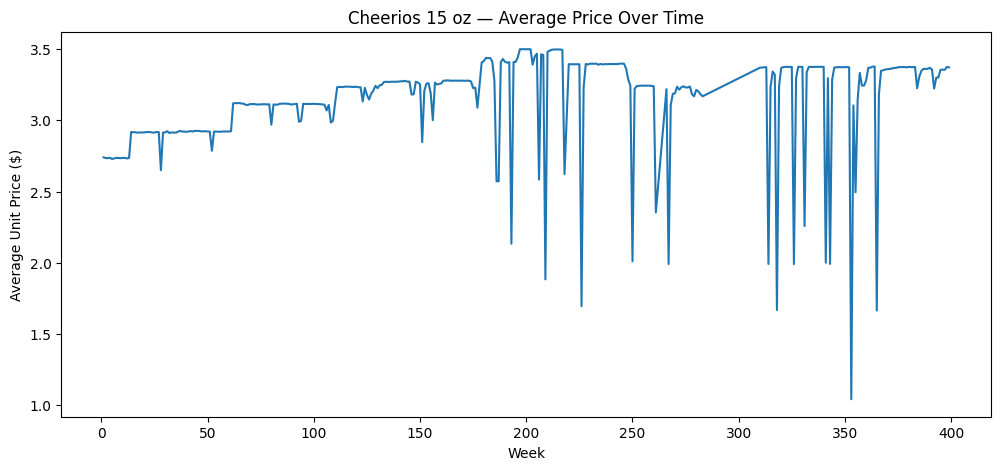

In [11]:
plt.figure(figsize=(12, 5))

plt.plot(
    cheerios_weekly["WEEK"],
    cheerios_weekly["avg_price"]
)

plt.xlabel("Week")
plt.ylabel("Average Unit Price ($)")
plt.title("Cheerios 15 oz — Average Price Over Time")

plt.show()

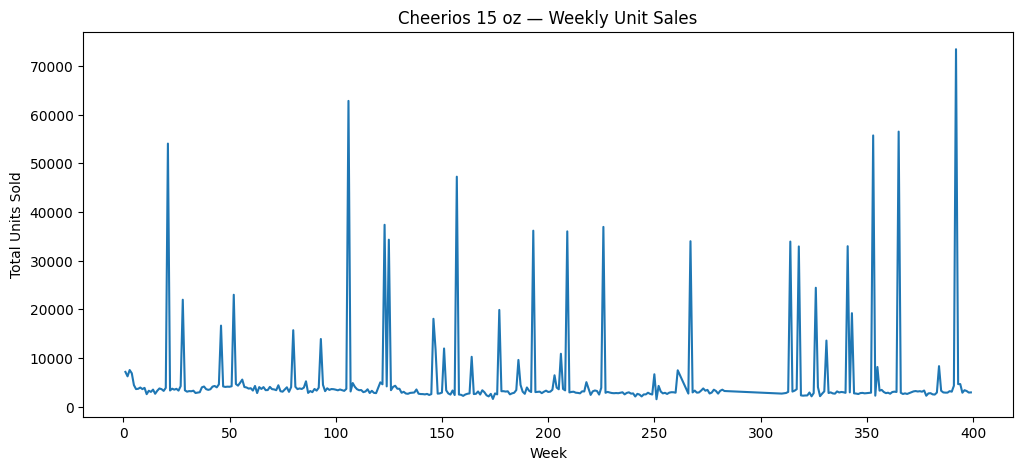

In [12]:
plt.figure(figsize=(12, 5))

plt.plot(
    cheerios_weekly["WEEK"],
    cheerios_weekly["total_units"]
)

plt.xlabel("Week")
plt.ylabel("Total Units Sold")
plt.title("Cheerios 15 oz — Weekly Unit Sales")

plt.show()

In [13]:
cheerios["PROMO_RECORDED"] = cheerios["SALE"].notna()

In [14]:
promo_summary = (
    cheerios.groupby("PROMO_RECORDED")
    .agg(
        observations=("MOVE", "size"),
        avg_price=("UNIT_PRICE", "mean"),
        avg_units=("MOVE", "mean"),
        avg_revenue=("REVENUE", "mean")
    )
)

promo_summary

,observations,avg_price,avg_units,avg_revenue
PROMO_RECORDED,,,,
False,26452,3.210025,51.513080,156.751241
True,3227,2.724884,201.176015,486.395060


In [15]:
cheerios["PROMO_RECORDED"].value_counts(normalize=True) * 100

PROMO_RECORDED
False    89.126992
True     10.873008
Name: proportion, dtype: float64

In [16]:
cheerios_price_demand = (
    cheerios.groupby("UNIT_PRICE")
    .agg(
        avg_units=("MOVE", "mean"),
        observations=("MOVE", "size")
    )
    .reset_index()
)

cheerios_price_demand.head()

,UNIT_PRICE,avg_units,observations
0,0.99,893.000000,3
1,1.00,844.500000,4
2,1.01,768.428571,7
3,1.02,821.571429,14
4,1.03,696.437500,16


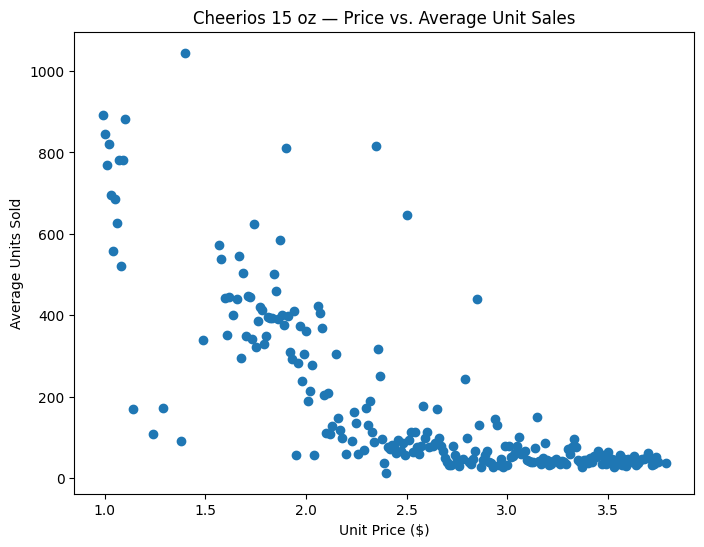

In [17]:
plt.figure(figsize=(8, 6))

plt.scatter(
    cheerios_price_demand["UNIT_PRICE"],
    cheerios_price_demand["avg_units"]
)

plt.xlabel("Unit Price ($)")
plt.ylabel("Average Units Sold")
plt.title("Cheerios 15 oz — Price vs. Average Unit Sales")

plt.show()

## 4. Promotion and Demand

Price changes may coincide with promotional activity, which can also affect
quantity sold. I examine observations with recorded promotion codes separately
before estimating the relationship between price and demand.

In [18]:
promo_type_summary = (
    cheerios.assign(
        SALE_CODE=cheerios["SALE"].fillna("No code recorded")
    )
    .groupby("SALE_CODE")
    .agg(
        observations=("MOVE", "size"),
        avg_price=("UNIT_PRICE", "mean"),
        avg_units=("MOVE", "mean"),
        median_units=("MOVE", "median"),
        avg_revenue=("REVENUE", "mean")
    )
    .sort_values("observations", ascending=False)
)

promo_type_summary

,observations,avg_price,avg_units,median_units,avg_revenue
SALE_CODE,,,,,
No code recorded,26452,3.210025,51.513080,36.0,156.751241
B,1701,2.997654,142.296884,59.0,377.793469
S,1281,2.411413,231.824356,159.0,513.540422
G,123,1.872683,413.227642,384.0,767.987724
C,122,3.072377,486.508197,462.0,1431.659016


In [19]:
store_summary = (
    cheerios.groupby("STORE")
    .agg(
        observations=("MOVE", "size"),
        avg_price=("UNIT_PRICE", "mean"),
        avg_units=("MOVE", "mean"),
        total_units=("MOVE", "sum")
    )
    .reset_index()
)

store_summary["avg_units"].describe()

count     93.000000
mean      68.226946
std       21.339398
min       35.389241
25%       50.693333
50%       67.718750
75%       81.727528
max      131.071895
Name: avg_units, dtype: float64

In [20]:
store_summary.sort_values(
    "avg_units",
    ascending=False
).head(10)

,STORE,observations,avg_price,avg_units,total_units
85,137,306,3.301797,131.071895,40108
83,135,45,3.049556,123.466667,5556
54,102,357,3.115574,111.809524,39916
60,109,359,3.274095,110.690808,39738
37,80,363,3.065537,110.013774,39935
12,44,358,3.124749,104.840782,37533
75,126,358,3.146760,102.737430,36780
41,86,362,3.180470,101.008287,36565
66,115,361,3.166510,100.800554,36389
72,122,362,3.096519,98.881215,35795


In [21]:
store_price_variation = (
    cheerios.groupby("STORE")
    .agg(
        avg_price=("UNIT_PRICE", "mean"),
        min_price=("UNIT_PRICE", "min"),
        max_price=("UNIT_PRICE", "max"),
        price_std=("UNIT_PRICE", "std"),
        unique_prices=("UNIT_PRICE", "nunique")
    )
    .reset_index()
)

store_price_variation["price_range"] = (
    store_price_variation["max_price"]
    - store_price_variation["min_price"]
)

store_price_variation[
    ["price_std", "unique_prices", "price_range"]
].describe()

,price_std,unique_prices,price_range
count,93.000000,93.000000,93.000000
mean,0.344113,39.806452,2.424839
std,0.050020,12.164862,0.387609
min,0.039854,3.000000,0.100000
25%,0.333868,38.000000,2.380000
50%,0.346073,41.000000,2.530000
75%,0.362047,46.000000,2.600000
max,0.454627,60.000000,2.770000


## 5. Implications for Elasticity Modeling

The exploratory analysis identifies several factors that should be considered
when estimating the relationship between price and demand.

- Prices vary substantially within most stores over time, providing useful
  variation for estimating demand response.
- Average sales differ considerably across stores, suggesting persistent
  store-level differences in demand.
- Recorded promotional activity is associated with both lower prices and
  substantially higher sales.
- Prices and sales also vary over time, so common time-specific demand
  conditions may confound the relationship between price and quantity.

These findings motivate a log-log demand model with store effects, time
controls, and promotion controls. Because the data are observational, the
resulting price coefficient will be interpreted as an estimated conditional
association rather than a definitive causal effect.

In [22]:
weekly_price_variation = (
    cheerios.groupby("WEEK")
    .agg(
        stores=("STORE", "nunique"),
        unique_prices=("UNIT_PRICE", "nunique"),
        price_std=("UNIT_PRICE", "std"),
        min_price=("UNIT_PRICE", "min"),
        max_price=("UNIT_PRICE", "max")
    )
    .reset_index()
)

weekly_price_variation["price_range"] = (
    weekly_price_variation["max_price"]
    - weekly_price_variation["min_price"]
)

weekly_price_variation[
    ["stores", "unique_prices", "price_std", "price_range"]
].describe()

,stores,unique_prices,price_std,price_range
count,366.000000,366.000000,366.000000,366.000000
mean,81.090164,7.644809,0.121357,0.543497
std,4.782395,7.097718,0.070988,0.441876
min,55.000000,1.000000,0.000000,0.000000
25%,80.000000,4.000000,0.084770,0.310000
50%,83.000000,5.000000,0.096256,0.390000
75%,84.000000,9.000000,0.162845,0.580000
max,86.000000,49.000000,0.672609,2.500000


In [23]:
weekly_price_variation.sort_values(
    "price_std"
).head(10)

,WEEK,stores,unique_prices,price_std,min_price,max_price,price_range
27,28,76,1,0.000000,2.65,2.65,0.00
92,93,82,1,0.000000,2.99,2.99,0.00
294,326,80,3,0.001591,1.98,2.00,0.02
309,341,80,2,0.001912,2.00,2.01,0.01
261,267,84,2,0.002380,1.99,2.00,0.01
282,314,80,3,0.003556,1.99,2.01,0.02
176,177,86,4,0.004903,3.05,3.09,0.04
311,343,80,4,0.005460,1.99,2.02,0.03
107,108,81,4,0.014412,2.94,3.01,0.07
93,94,83,6,0.015358,2.99,3.08,0.09
